In [1]:
import os
import glob
import os
from scipy.io import mmwrite
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import re
import gget
import psutil
from scipy.stats import zscore

import rmm
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/processed/sample_1_adata.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 10.9 s, sys: 33.3 s, total: 44.1 s
Wall time: 55.6 s


AnnData object with n_obs × n_vars = 1125041 × 52164
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette

In [4]:
rsc.get.anndata_to_GPU(adata) # move to GPU
rsc.pp.filter_genes(adata, min_counts=500)
adata

filtered out 23626 genes that are detected in less than 500 counts


AnnData object with n_obs × n_vars = 1125041 × 28538
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'basename', 'dataset_id_int', 'n_counts', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'X_umap_X_scANVI', 'X_umap_raw_data', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'basename_colors', 'basename_palette

In [5]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/basename_ref.h5ad"

aggdata = sc.get.aggregate(
    adata,
    by='basename',
    func='sum',
    layer='counts',
)

aggdata.X = aggdata.layers['sum']
del aggdata.layers['sum']
print(f"{aggdata.shape=}")
aggdata.write(outpath)
aggdata.obs.head()


aggdata.shape=(8, 28538)
CPU times: user 12.9 s, sys: 20.1 s, total: 33.1 s
Wall time: 33.9 s


,basename
endothelial_cells,endothelial_cells
fibroblasts,fibroblasts
hematopoietic_progenitors,hematopoietic_progenitors
hsc,hsc
innate_lymphoid_cells,innate_lymphoid_cells


In [6]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/cell_type_ref.h5ad"

aggdata = sc.get.aggregate(
    adata,
    by='cell_type',
    func='sum',
    layer='counts',
)

aggdata.X = aggdata.layers['sum']
del aggdata.layers['sum']
print(f"{aggdata.shape=}")
aggdata.write(outpath)
aggdata.obs.head()


aggdata.shape=(188, 28538)
CPU times: user 10.6 s, sys: 11 s, total: 21.7 s
Wall time: 22.5 s


,cell_type
B-1 B cell,B-1 B cell
B-1a B cell,B-1a B cell
B-1b B cell,B-1b B cell
B-2 B cell,B-2 B cell
CD1c-positive myeloid dendritic cell,CD1c-positive myeloid dendritic cell


In [7]:
counts = adata.obs['cell_type'].value_counts().reset_index()
counts = counts.sort_values('cell_type')
print(counts.to_string(index=False))

                                                                           cell_type  count
                                                                          B-1 B cell    268
                                                                         B-1a B cell     15
                                                                         B-1b B cell     31
                                                                          B-2 B cell    887
                                                CD1c-positive myeloid dendritic cell   5217
                                                          CD4-positive helper T cell   3551
                           CD4-positive, CD25-positive, alpha-beta regulatory T cell     87
                                           CD4-positive, alpha-beta cytotoxic T cell   2050
                                              CD4-positive, alpha-beta memory T cell   2529
                                                  CD4-positive, alpha-beta thymo

In [8]:
# %%time
# # Aggregate data by cell_type
# aggdata = sc.get.aggregate(
#     adata, by='cell_type', func='sum', layer='counts'
# )
# aggdata.X = aggdata.layers['sum']
# X = aggdata.to_df()
# A = X.T.corr()

# # Move correlation matrix to GPU
# A_gpu = cudf.DataFrame(A)
# n = A_gpu.shape[0]
# tril_idx = cp.tril_indices(n, k=-1)
# values = A_gpu.to_cupy()[tril_idx]

# # X, A are pandas DataFrames
# rows = np.array(A.index.tolist())
# cols = np.array(A.columns.tolist())

# # Now move to GPU for further processing
# A_gpu = cudf.DataFrame(A)
# n = A_gpu.shape[0]
# tril_idx = cp.tril_indices(n, k=-1)
# values = A_gpu.to_cupy()[tril_idx]

# row_idx = rows[cp.asnumpy(tril_idx[0])]
# col_idx = cols[cp.asnumpy(tril_idx[1])]

# all_pairs = cudf.DataFrame({
#     'row': row_idx,
#     'col': col_idx,
#     'val': cp.asnumpy(values)
# })

# # Greedy max-spread selection
# vals = all_pairs['val'].to_cupy()
# selected_idx = [int(cp.argmin(vals)), int(cp.argmax(vals))]
# for _ in range(18):
#     mask = cp.ones(len(vals), dtype=bool)
#     mask[selected_idx] = False
#     dists = cp.min(cp.abs(vals[mask][:, None] - vals[selected_idx]), axis=1)
#     next_rel_idx = int(cp.argmax(dists))
#     abs_idx = cp.arange(len(vals))[mask][next_rel_idx]
#     selected_idx.append(int(abs_idx))

# print(all_pairs.iloc[selected_idx])

In [9]:
# g = sns.clustermap(
#     A,
#     cmap="vlag",               # Diverging, perceptually uniform
#     linewidths=0.3,
#     linecolor='white',
#     figsize=(35, 35),
#     square=True,
#     cbar_kws={'label': 'Correlation'},
#     xticklabels=True,
#     yticklabels=True,
#     annot=True,
#     dendrogram_ratio=(0.25, 0.25),    # Small dendrograms
#     cbar_pos=(0.02, 0.8, 0.03, 0.18), # Custom colorbar position (optional)
# )

# plt.suptitle("Clustered Correlation Matrix", fontsize=15, y=1.02)
# plt.show()

# Hand-selected cell types + downsampling

In [10]:
%%time
cell_types = [
    'embryonic fibroblast',
    'skin fibroblast',
    # 'fibro/adipogenic progenitor cell',
    'hematopoietic stem cell',
    # 'cord blood hematopoietic stem cell',
    'common myeloid progenitor',
    'early lymphoid progenitor',
    'megakaryocyte-erythroid progenitor cell',
    'granulocyte monocyte progenitor cell',
    'hematopoietic multipotent progenitor cell',
    'endothelial cell of artery',
    'endothelial cell of lymphatic vessel',
    'vein endothelial cell',
]
sample_size = 5000

print("[INFO] Filtering AnnData for selected cell types...")
bdata = adata[adata.obs['cell_type'].isin(cell_types)].copy()
print(f"[INFO] Shape after cell type filtering: {bdata.shape}")

# Remove duplicate obs_names
print("[INFO] Removing duplicate obs_names...")
duplicates = bdata.obs_names.duplicated(keep='first')
n_duplicates = duplicates.sum()
if n_duplicates > 0:
    print(f"[INFO] Found {n_duplicates} duplicate cells. Removing.")
    bdata = bdata[~duplicates].copy()
else:
    print("[INFO] No duplicate cells found.")
print(f"[INFO] Shape after duplicate removal: {bdata.shape}")

print("[INFO] Cell counts per type (before downsampling):")
print(bdata.obs['cell_type'].value_counts().to_string())
print("="*60)

# Downsample cells per type
print(f"[INFO] Sampling up to {sample_size} cells per cell type...")
grouped = bdata.obs.groupby('cell_type', observed=True)
sampled_indices = []
for cell_type, group in grouped:
    n = min(sample_size, len(group))
    sampled = group.sample(n=n, random_state=0).index.tolist()
    sampled_indices.extend(sampled)

# Now sampled_indices is a flat list of obs_names
bdata = bdata[sampled_indices, :].copy()
print(f"[INFO] Shape after downsampling: {bdata.shape}")

min_counts = 25
print(f"[INFO] Filtering genes based on min counts: {min_counts}")
rsc.pp.filter_genes(bdata, min_counts = min_counts)
print(f"[INFO] Filtered shape: {bdata.shape}")

# n_hvg = 1000
# print(f"[INFO] Filtering {n_hvg} HVG...")
# rsc.pp.highly_variable_genes(bdata, n_top_genes=n_hvg, batch_key='cell_type')
# bdata = bdata[:, bdata.var['highly_variable']].copy()
# print(f"[INFO] Filtered shape: {bdata.shape}")

print("\n[INFO] Cell counts per type (after downsampling):")
print(bdata.obs['cell_type'].value_counts().to_string())
print("="*60)

[INFO] Filtering AnnData for selected cell types...
[INFO] Shape after cell type filtering: (116913, 28538)
[INFO] Removing duplicate obs_names...
[INFO] Found 6920 duplicate cells. Removing.
[INFO] Shape after duplicate removal: (109993, 28538)
[INFO] Cell counts per type (before downsampling):
cell_type
hematopoietic multipotent progenitor cell    19820
vein endothelial cell                        18914
skin fibroblast                              17272
endothelial cell of lymphatic vessel         14759
hematopoietic stem cell                      12603
endothelial cell of artery                    8854
megakaryocyte-erythroid progenitor cell       7169
granulocyte monocyte progenitor cell          3608
early lymphoid progenitor                     2690
common myeloid progenitor                     2595
embryonic fibroblast                          1709
[INFO] Sampling up to 5000 cells per cell type...
[INFO] Shape after downsampling: (45602, 28538)
[INFO] Filtering genes based on mi

# Aggregation (pseudobulk)

In [11]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/hand_select.h5ad"

agg = 'sum'

aggdata = sc.get.aggregate(
    bdata,
    by='cell_type',
    func=agg,
    layer='counts',
)

aggdata.X = aggdata.layers[agg]
del aggdata.layers[agg]
print(f"{aggdata.shape=}")
aggdata.write(outpath)
aggdata.obs.head()

aggdata.shape=(11, 23858)
CPU times: user 452 ms, sys: 438 ms, total: 890 ms
Wall time: 989 ms


,cell_type
common myeloid progenitor,common myeloid progenitor
early lymphoid progenitor,early lymphoid progenitor
embryonic fibroblast,embryonic fibroblast
endothelial cell of artery,endothelial cell of artery
endothelial cell of lymphatic vessel,endothelial cell of lymphatic vessel


X.shape=(11, 23858)
A.shape=(11, 11)


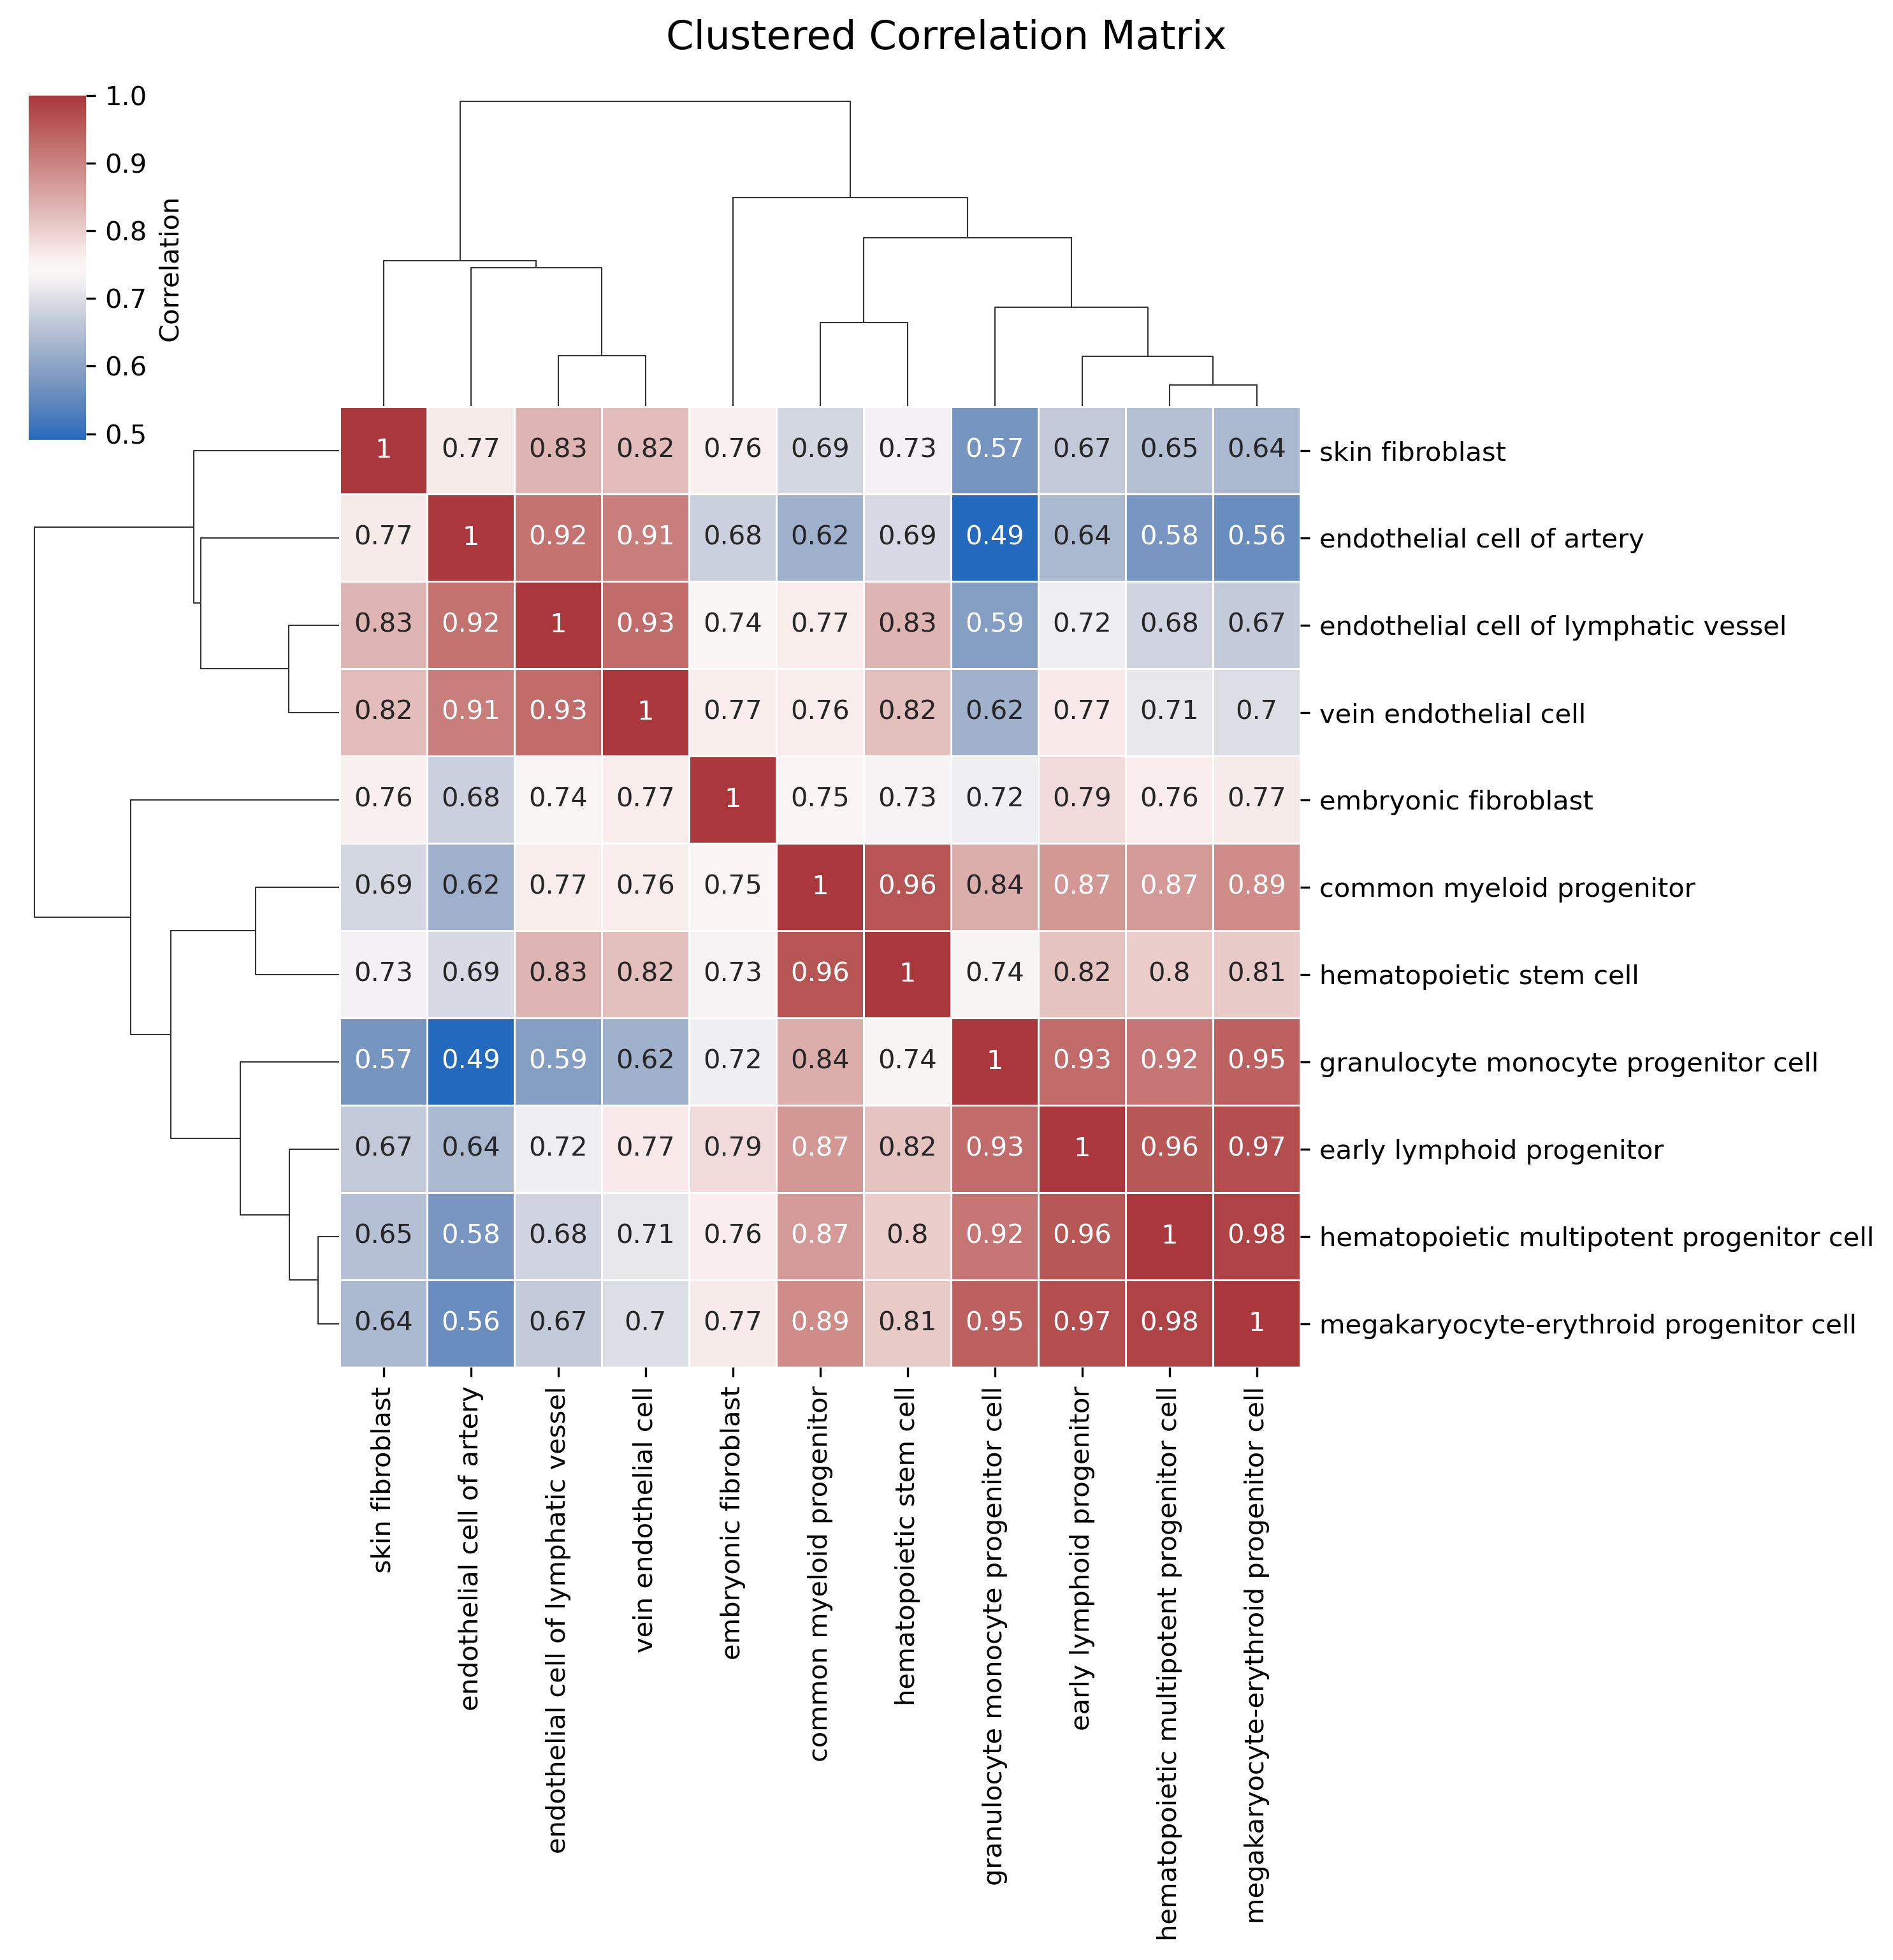

In [12]:
X = aggdata.to_df()
print(f"{X.shape=}")
A = X.T.corr()
print(f"{A.shape=}")

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

g = sns.clustermap(
    A,
    cmap="vlag",               # Diverging, perceptually uniform
    linewidths=0.3,
    linecolor='white',
    figsize=(10, 10),
    square=True,
    cbar_kws={'label': 'Correlation'},
    xticklabels=True,
    yticklabels=True,
    annot=True,
    dendrogram_ratio=(0.25, 0.25),    # Small dendrograms
    cbar_pos=(0.02, 0.8, 0.03, 0.18), # Custom colorbar position (optional)
)

plt.suptitle("Clustered Correlation Matrix", fontsize=15, y=1.02)
plt.show()

In [13]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)